# March Madness Rating Computation

In [110]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, brier_score_loss, mean_absolute_error, log_loss
from scipy.interpolate import UnivariateSpline, InterpolatedUnivariateSpline # interpolate win margin model to probabilities
from datetime import datetime
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, RobustScaler, MinMaxScaler


In [111]:
start = '20120101'
end = '20231231'
match_type = 'm'

In [112]:
start_date = datetime.strptime(start, '%Y%m%d').date()
end_date = datetime.strptime(end, '%Y%m%d').date()

RD_CUTOFF = 360

df = pd.read_csv('../../testcsvs/StephFixDouble25.csv')
df['tourney_date'] = pd.to_datetime(df['tourney_date']).dt.date
df = df[(df['tourney_date'] >= start_date) & (df['tourney_date'] <= end_date)]
# df = df[(df['a_glicko_rd'] <= RD_CUTOFF) & (df['b_glicko_rd'] <= RD_CUTOFF)]

df = df.drop(['tourney_id', 'tourney_name', 'match_num', 'tourney_date', 'a_player_name', 'b_player_name', 'a_player_id', 'a_player_slug', 'b_player_id', 'b_player_slug', 'sets', 'games', 'tiebreaks'], axis=1)
# print(df.duplicated().sum())

print(len(df))

one_hot_encoder = OneHotEncoder(sparse_output=False)

# One-Hot Encode the 'category_text' column
category_encoded = one_hot_encoder.fit_transform(df[['surface']])

# Convert to DataFrame
category_encoded_df = pd.DataFrame(category_encoded, columns=one_hot_encoder.get_feature_names_out(['surface']))

# Concatenate the one-hot encoded columns back to the original DataFrame
df = pd.concat([df.reset_index(drop=True), category_encoded_df], axis=1)

# Drop the original 'category_text' column
df.drop('surface', axis=1, inplace=True)
# print(df.duplicated().sum())

print(len(df))

62842
62842


# March Madness teams - team strength overview

In [113]:




# # Normalize features
# # scaler = StandardScaler()
# # X = scaler.fit_transform(X)

# # Split data
# X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
#     X, y, df.index, test_size=0.3, random_state=42
# )

# X_validate, X_test, y_validate, y_test, idx_validate, idx_test = train_test_split(
#     X_temp, y_temp, idx_temp, test_size=0.5, random_state=42
# )

# # Convert to DataFrames for model compatibility
# df_train = pd.DataFrame(X_train, columns=df.columns)
# df_train['Result'] = y_train

# df_validate = pd.DataFrame(X_validate, columns=df.columns)
# df_validate['Result'] = y_validate

# df_test = pd.DataFrame(X_test, columns=df.columns)
# df_test['Result'] = y_test

# # Train model
# selected_features = df_train.columns.drop('Result').tolist()
# model = trainModel(selected_features, df_train, df_validate)

# # Evaluate model
# evaluation_metrics = evaluateModel(model, df_validate, selected_features)

# print(f"Accuracy: {evaluation_metrics['accuracy']:.4f}")
# print(f"AUC: {evaluation_metrics['auc']:.4f}")

# # Feature importance
# importances = model.feature_importance()
# feature_importance_df = pd.DataFrame({'Feature': selected_features, 'Importance': importances})
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# # Plot feature importance
# plt.figure(figsize=(15, 10))
# plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.title('Feature Importance')
# plt.gca().invert_yaxis()
# plt.show()

# # Save model
# model.save_model('lightgbm_model.txt')

# # Predictions
# y_pred = model.predict(X_test)

# # Ensure correct odds indexing
# odds_test = odds_df.loc[idx_test].values

# # Create results DataFrame
# results_df = pd.DataFrame({
#     'Actual': y_test,
#     'Predicted': y_pred,
#     'A_Odds': odds_test[:, 0],
#     'B_Odds': odds_test[:, 1]
# })

# # Save predictions
# # results_df.to_csv('predictions_with_odds.csv', index=False)

# # Plot ROC curve
# fpr, tpr, _ = roc_curve(y_test, y_pred)  # Use probabilities
# plt.plot(fpr, tpr)
# plt.title("Receiver Operating Characteristics")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.show()

In [114]:
def cauchyobj(preds, dtrain):
    labels = dtrain.get_label()
    c = 5000 
    x =  preds-labels    
    grad = x / (x**2/c**2+1)
    hess = -c**2*(x**2-c**2)/(x**2+c**2)**2
    return grad, hess

In [115]:
# build proxy models to predict win margin
# Data cleaning and filtering
df = df.dropna()

# Uncomment and use if necessary
# df = df[(df['surface_Hard'] == 1.0)]
# df = df[(df['tourney_level'] == 6)]

# Extract odds before dropping them from df
odds_df = df[['a_odds', 'b_odds']].copy()
odds_df.index = df.index  # Ensure proper indexing

df = df.drop(columns=['a_odds', 'b_odds', 'a_b_win'])  # Remove odds from feature set
# df = df.drop(columns=['a_b_win'])  # Remove odds from feature set

# Define features and target
y = df.pop('point_diff').values

# df = df[[col for col in df.columns if "diff" not in col]]

X = df.values  # Use NumPy array for better efficiency
features = df.columns

param = {} 
param['eval_metric'] =  'mae'
# param['objective'] = 'reg:squarederror'
param['booster'] = 'gbtree'
param['eta'] = 0.01
param['subsample'] = 0.35
param['colsample_bytree'] = 0.7
param['num_parallel_tree'] = 10 #best so far
param['min_child_weight'] = 40
param['gamma'] = 10
param['max_depth'] =  3

num_rounds = 1000

# models = {}
oof_mae = []
oof_preds = []
oof_targets = []

x_train, x_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)


# Training
dtrain = xgb.DMatrix(x_train, label=y_train)
dval = xgb.DMatrix(x_val, label=y_val)
model = xgb.train(
    params=param, 
    dtrain=dtrain, 
    num_boost_round=num_rounds,
    obj = cauchyobj #Test further
    )

# Predictions
preds = model.predict(dval)
mae = mean_absolute_error(y_val, preds)
print(f'MAE: {mae:.4f}')

# Store out-of-fold results
oof_preds = np.array(preds)
oof_targets = np.array(y_val)



MAE: 11.3746


brier: 0.20203442689305137
acc: 0.6805304400241109
roc: 0.7516130290274979


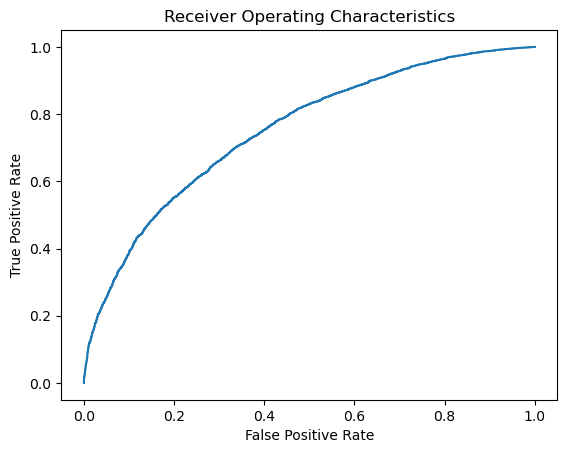

In [116]:
t = 30

dat = list(zip(oof_preds, (oof_targets > 0).astype(int)))
dat = sorted(dat, key=lambda x: x[0])
pred, label = list(zip(*dat))

spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k=3)
spline_fit = np.clip(spline_model(np.clip(oof_preds, -t, t)), 0, 1)

print(f"brier: {brier_score_loss(np.array(oof_targets)>0, spline_fit)}")

pred_binary = [1 if x_pred > 0.5 else 0 for x_pred in spline_fit]

print(f"acc: {accuracy_score(np.array(oof_targets)>0, pred_binary)}")
print(f"roc: {roc_auc_score(np.array(oof_targets)>0, spline_fit)}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(np.array(oof_targets)>0, spline_fit)  # Use probabilities
plt.plot(fpr, tpr)
plt.title("Receiver Operating Characteristics")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

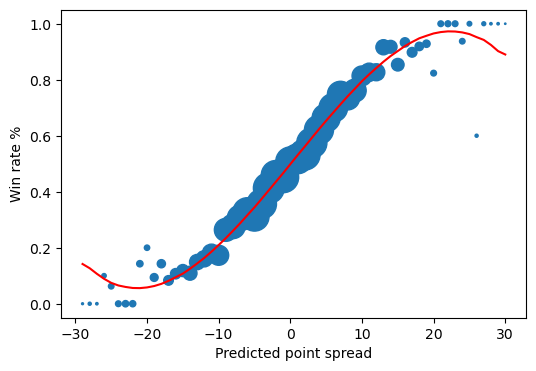

In [117]:
# win margin model predictions and win probability spline fit on the same plot
df = pd.DataFrame({'pred': np.round(oof_preds,0), 
                   'label': np.array(oof_targets)>0, 
                   'spline_fit': spline_fit})
df = df.groupby('pred')[['label', 'spline_fit']].agg(['mean', 'count']).reset_index()

fig, ax1 = plt.subplots(figsize = (6,4))
ax1.scatter(df['pred'], df['label']['mean'], df['label']['count'])
ax1.plot(df['pred'], df['spline_fit']['mean'], 'r')
ax1.set_xlabel('Predicted point spread')
ax1.set_ylabel('Win rate %')
plt.show()

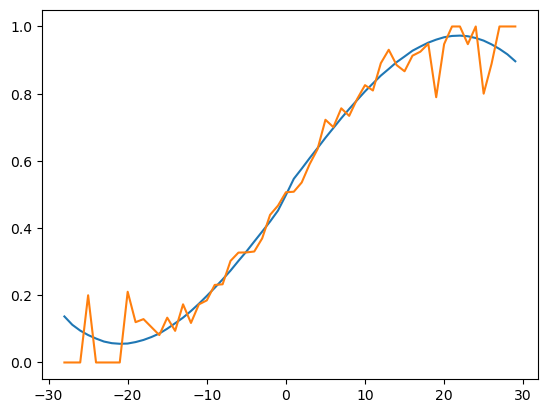

In [118]:
plot_df = pd.DataFrame({"pred": oof_preds, "label": (np.array(oof_targets) > 0).astype(int), "spline": spline_fit})

plot_df["pred_int"] = plot_df["pred"].astype(int)
plot_df = plot_df.groupby('pred_int')[['spline', 'label']].mean().reset_index()


plt.figure()
plt.plot(plot_df.pred_int,plot_df.spline)
plt.plot(plot_df.pred_int,plot_df.label)

In [119]:
results_df = pd.DataFrame({
    'Actual': (y_val > 0).astype(int),
    'Predicted': spline_fit,
    'A_Odds': odds_df.loc[idx_val, 'a_odds'].values,
    'B_Odds': odds_df.loc[idx_val, 'b_odds'].values
}, index=idx_val)

results_df.head()

,Actual,Predicted,A_Odds,B_Odds
57636,0,0.312142,2.76,1.46
46403,1,0.555751,1.77,2.05
27295,0,0.089000,7.18,1.09
32598,1,0.866898,1.16,5.18
17687,1,0.392104,2.80,1.41


In [120]:
# Kelly Criterion
def kelly_criterion(vegas_odds, calculated_probability):
    corrected = vegas_odds - 1
    # Calculate the Kelly fraction
    kelly_fraction = calculated_probability - ((1 - calculated_probability)/corrected)
    # Ensure that the fraction is not negative
    kelly_fraction = max(0, kelly_fraction)
    
    return kelly_fraction

In [135]:
better = 0
total_won = 0
diff_fav = 0
bet_correct = 0

upset_predict = 0
upset_correct = 0
upset_won = 0

model_correct = 0
vegas_correct = 0
vegas_total = 0

wrong = 0
comparison_df = results_df.dropna()
length = len(comparison_df)

avg_bet = 0

confidence_pct = .7
confidence_top_pct = 1

START_UNIT = 10
UNIT = START_UNIT

for i, row in comparison_df.iterrows():
    current = START_UNIT
    if confidence_top_pct > row['Predicted'] > confidence_pct :
        kelly = (kelly_criterion(row['A_Odds'], row['Predicted']) * UNIT)
        better += 1 if kelly > 0 else 0
        avg_bet += kelly_criterion(row['A_Odds'], row['Predicted'])
        if(row['Actual'] == 1):
            bet_correct += 1 if kelly > 0 else 0
            START_UNIT += (row['A_Odds']-1) * kelly
        else:
            wrong += 1 if kelly > 0 else 0
            START_UNIT -= kelly

    if 1-confidence_top_pct < row['Predicted'] < 1-confidence_pct :
        kelly = (kelly_criterion(row['B_Odds'], 1-row['Predicted']) * UNIT)
        better += 1 if kelly > 0 else 0
        avg_bet += kelly_criterion(row['B_Odds'], 1-row['Predicted'])
        if(row['Actual'] == 0):
            bet_correct += 1 if kelly > 0 else 0
            START_UNIT += (row['B_Odds']-1) * kelly
        else:
            wrong += 1 if kelly > 0 else 0
            START_UNIT -= kelly

    if round(row['Predicted']) != round(1/row['A_Odds']):
        diff_fav += 1

        kelly_A  = (kelly_criterion(row['A_Odds'],row['Predicted']) * UNIT)
        kelly_B  = (kelly_criterion(row['B_Odds'],1-row['Predicted']) * UNIT)

        upset_predict += 1 if (kelly_A > 0 and round(row['Predicted']) == 1) or (kelly_B > 0 and round(row['Predicted']) == 0) else 0

        if round(row['Predicted']) == round(row['Actual']):
            if(row['Actual'] == 1):
                upset_correct += 1 if kelly_A > 0 else 0
                upset_won += (row['A_Odds']-1) * kelly_A
            else:
                upset_correct += 1 if kelly_B > 0 else 0
                upset_won += (row['B_Odds']-1) * kelly_B
        elif round(row['Predicted']) == 1:
            upset_won -= kelly_A
        else:
            upset_won -= kelly_B
            
    if row['Actual']==1 and row['A_Odds'] < row['B_Odds']:
        # print(f"A odds : {row['a_odds']} B odds : {row['b_odds']}")
        vegas_correct += 1

    if row['Actual']==0 and row['A_Odds'] > row['B_Odds']:
        vegas_correct += 1

    if round(row['Predicted']) == round(row['Actual']):
        model_correct += 1


print(f"Total returned on Starting ${UNIT} bankroll: {START_UNIT:.2f} on a total # bets: {better} from a total of {length} games")
print(f"ROI : {((START_UNIT-UNIT)/UNIT):.1f} X")
print(f"Avg Bankroll Bet % : {(avg_bet/better):.3f} %") if better > 0 else print("", end="")
print(f"Amount of differing favorites %: {(diff_fav/length):.3f}")
print(f"Amount of upset bets correct % : {(upset_correct/upset_predict):.3f} with Unit ${UNIT} won ${upset_won:.2f} on {upset_predict} bets")
print(f"Amount of incorrect bet % : {(wrong/better):.4f}") if better > 0 else print("", end="")
print(f"Correct Bet %: {(bet_correct/better):.4f}") if better > 0 else print("", end="")
print(f"Model % Correct : {(model_correct/length):.4f} Vegas Correct % : {(vegas_correct/length):.4f}")


Total returned on Starting $10 bankroll: 49.75 on a total # bets: 1450 from a total of 9954 games
ROI : 4.0 X
Avg Bankroll Bet % : 0.237 %
Amount of differing favorites %: 0.122
Amount of upset bets correct % : 0.438 with Unit $10 won $-117.57 on 1142 bets
Amount of incorrect bet % : 0.2600
Correct Bet %: 0.7400
Model % Correct : 0.6805 Vegas Correct % : 0.6983


In [122]:
# # sanity check to check for win probability distribution
# m = X.loc[(~pd.isnull(X.T1_seed)) & (~pd.isnull(X.T2_seed))]
# plt.figure(figsize=(6, 3))
# plt.xlim(0, 1)
# sns.histplot(m['Pred'], bins=42)